# Metropolitan bicycle sharing system:  How many bicycles need to be ready at a given time

Data was taken from https://www.kaggle.com/c/bike-sharing-demand/data in April 2020

In [63]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_log_error, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

import math
from pprint import pprint

# import warnings
# warnings.filterwarnings('ignore')

In [2]:
#load train.csv data from kaggle into notebook
df = pd.read_csv('data/train.csv', index_col=0, parse_dates=True)
df.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
datetime,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


# Preprocessing: Date time conversion

### Months and Hours

In [3]:
# Create a new column "hour" (every 1h that is available from index data)
df['hour'] = df.index.hour

# Create a new column "month"(every 1M that is available from index data)
df['month'] = df.index.month

df.head(3)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,month
datetime,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,1


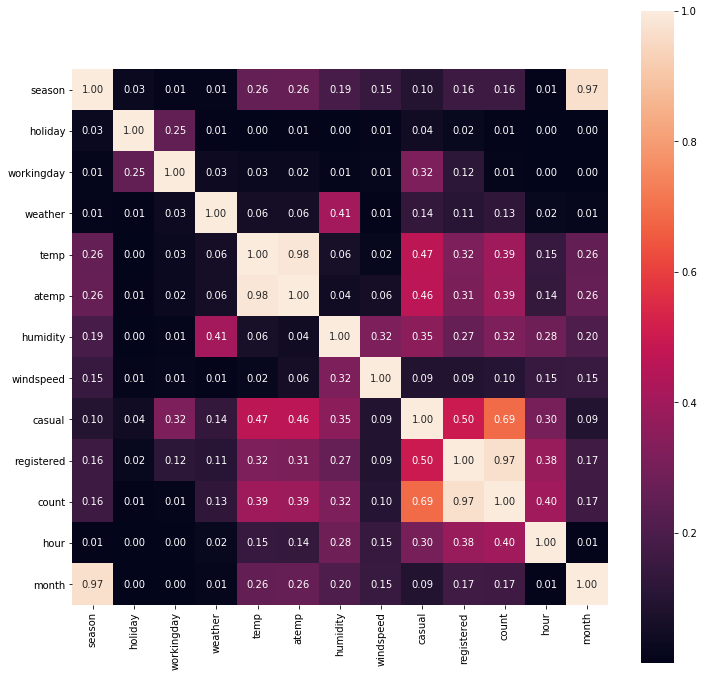

In [4]:
#plot data in a heatmap for first view on correlations
plt.figure(figsize=[12,12])
sns.heatmap(df.corr().abs(), annot=True, fmt='.2f', square=True)

On the first sight, you can see that obviously some columns already correlate well with each other. Therefore, redundant features can be eliminated:
 - atemp: is displayed in temp
 - season: is displaye in month (and month seems to be more precise as season)
 - registered and casual: are aggregated in count

In [5]:
df = df.drop(['atemp'], axis=1)
df = df.drop(['season'], axis=1)
df = df.drop(['registered','casual'], axis=1)
df.head(3)

,holiday,workingday,weather,temp,humidity,windspeed,count,hour,month
datetime,,,,,,,,,
2011-01-01 00:00:00,0,0,1,9.84,81,0.0,16,0,1
2011-01-01 01:00:00,0,0,1,9.02,80,0.0,40,1,1
2011-01-01 02:00:00,0,0,1,9.02,80,0.0,32,2,1


Workingday and holiday don't seem to be indirectly proportional so that we cannot eliminate one of these two columns. For information, we could have a closer look, how many entries share the same values (0 or 1) for holiday and workingday:

In [6]:
#df[df['holiday']==df['workingday']].shape
(df['holiday']==df['workingday']).value_counts()

False    7723
True     3163
dtype: int64

### Weather

As weather is represented in categorical variables (four numbers) we need to one hot encode these, first.

In [7]:
# Use One-Hot-Encoding
df_weather_OHE = pd.get_dummies(df['weather'])
df = pd.concat([df, df_weather_OHE], axis=1)

# to not get confused with the numbers as column names --> rename column names                  
df.rename(columns={1: 'w1', 2:'w2', 3:'w3', 4:'w4'}, inplace=True)

# drop the 'weather' column as weather is now displayed as w1,w2,...
df = df.drop(['weather'], axis=1)

df.head(3)

,holiday,workingday,temp,humidity,windspeed,count,hour,month,w1,w2,w3,w4
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,0,0,9.84,81,0.0,16,0,1,1,0,0,0
2011-01-01 01:00:00,0,0,9.02,80,0.0,40,1,1,1,0,0,0
2011-01-01 02:00:00,0,0,9.02,80,0.0,32,2,1,1,0,0,0


## Display correlations in a heatmap

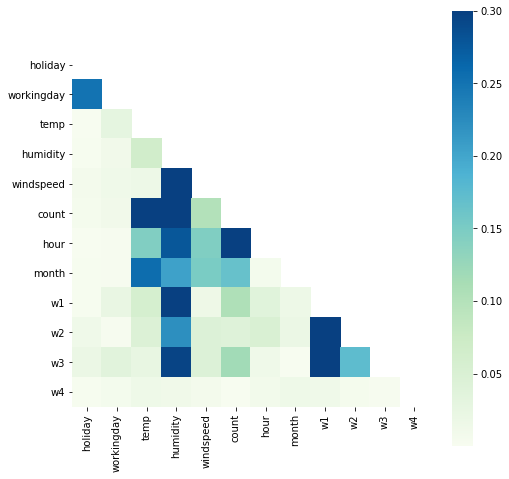

In [8]:
mask = np.triu(np.ones_like(df.corr().abs(), dtype=np.bool))

plt.figure(figsize=(8,8))
sns.heatmap(df.corr().abs(), 
            mask=mask, 
            cmap="GnBu", 
            vmax=.3,
            square=True,
            annot=False ) 

These features are obviously correlating with 'count':
- temp
- humidity
- casual
- registered

In [9]:
df.columns

Index(['holiday', 'workingday', 'temp', 'humidity', 'windspeed', 'count',
       'hour', 'month', 'w1', 'w2', 'w3', 'w4'],
      dtype='object')

### Final DataFrame Analysis before the Machine Learning part begins

#### First, check if there are any NaN in the dataset

In [12]:
# Possibility 1:
df.isna().values.any()

False

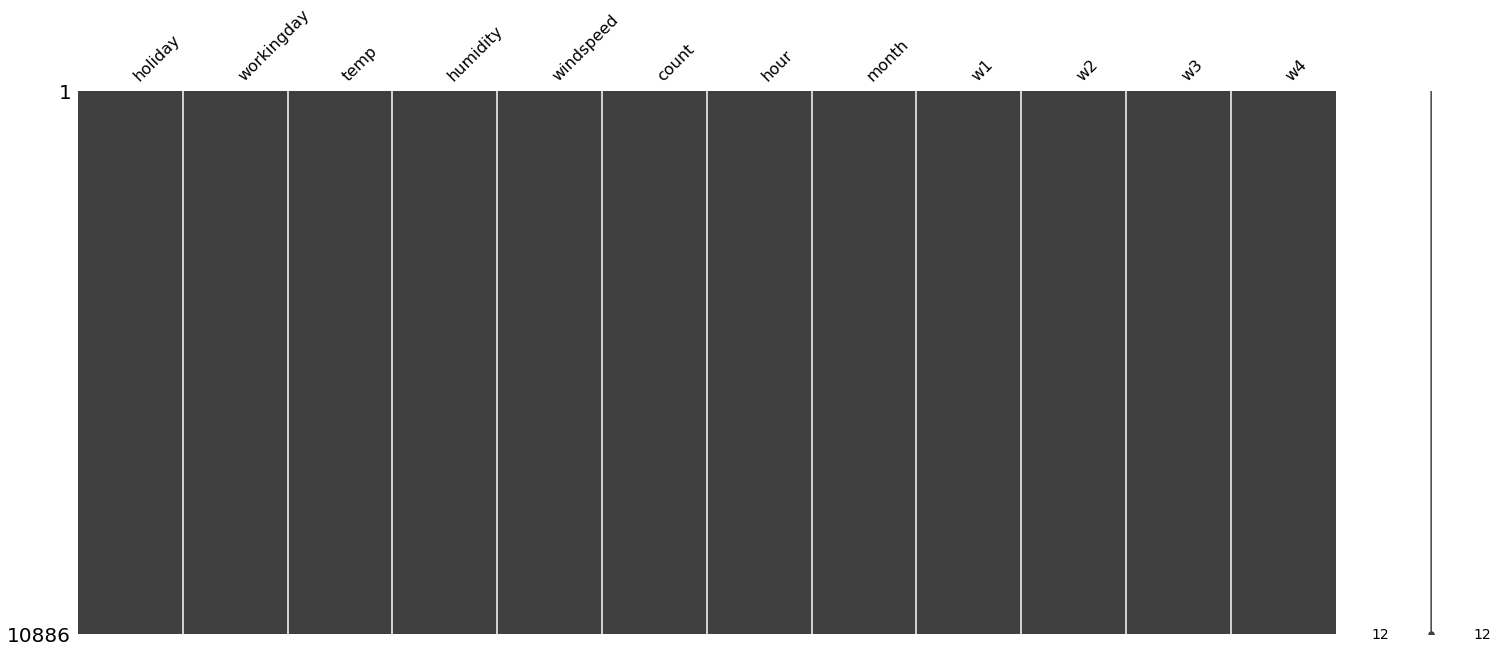

In [27]:
# Possiblity 2: Visualize missing values (NaN)
import missingno as msno
msno.matrix(df)

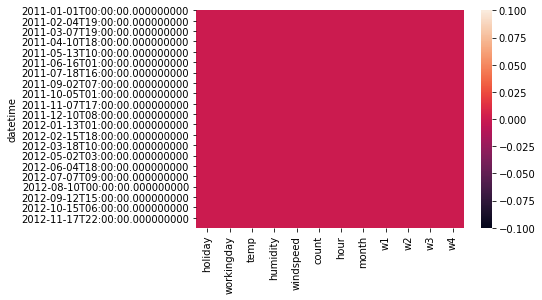

In [55]:
# Possibility 3:
sns.heatmap(df.isna())

In [13]:
# check for dimensionality if needed
df.shape

(10886, 12)

In [14]:
# generate descriptive statistics
df.describe()

,holiday,workingday,temp,humidity,windspeed,count,hour,month,w1,w2,w3,w4
count,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,0.028569,0.680875,20.23086,61.886460,12.799395,191.574132,11.541613,6.521495,0.660665,0.260334,0.078909,0.000092
std,0.166599,0.466159,7.79159,19.245033,8.164537,181.144454,6.915838,3.444373,0.473505,0.438837,0.269609,0.009584
min,0.000000,0.000000,0.82000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,13.94000,47.000000,7.001500,42.000000,6.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,20.50000,62.000000,12.998000,145.000000,12.000000,7.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,1.000000,26.24000,77.000000,16.997900,284.000000,18.000000,10.000000,1.000000,1.000000,0.000000,0.000000
max,1.000000,1.000000,41.00000,100.000000,56.996900,977.000000,23.000000,12.000000,1.000000,1.000000,1.000000,1.000000


# Data Assignment

In [64]:
Xy = df[['holiday', 'workingday', 'temp', 'humidity', 'count',
        'windspeed', 'hour', 'month', 'w1', 'w2', 'w3', 'w4']]

#Xy = Xy.dropna()  """not nescessary here as there are no NaN"""
y = Xy['count']
X = Xy.drop(['count'], axis = 1)

In [65]:
# MinMax Scaling --> first create DataFrame
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X))

In [66]:
#split train.csv from kaggle into test and train data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=102)

# Machine Learning and Prediction

First, try to optimize the hyperparameters for the different regression models

### Try 'RidgeCV'

In [68]:
alphas_values = np.array([3,2,1,0.1,0.01,0.001,0.0001])
ridgeCV = RidgeCV(alphas=alphas_values)

parameter_grid_ridgeCV={'cv': ([5,6,7,8,9,10,11,12])}

reg = GridSearchCV(estimator=ridgeCV, param_grid=parameter_grid_ridgeCV, n_jobs=-1)
reg.fit(X_train, y_train)

#for information print best settings
print('Best score:', reg.best_score_)
print('Best alphas: ', reg.best_estimator_.alpha_)
print('Best cv: ', reg.best_estimator_.cv)

Best score: 0.3358969586100416
Best alphas:  3.0
Best cv:  5


### Try 'ElasticNet'

In [69]:
eNet = ElasticNet()

parameter_grid_eNet={'alpha': ([3,2,1,0.1,0.01,0.001,0.0001,0]),
                     'l1_ratio': ([0.01, 0.25, 0.5, 0.75, 1])
                    }

reg = GridSearchCV(estimator=eNet, param_grid=parameter_grid_eNet, n_jobs=-1)
reg.fit(X_train, y_train)

#for information print best settings
print('Best score:', reg.best_score_)
print('Best alpha: ', reg.best_estimator_.alpha)
print('Best l1_ratio: ', reg.best_estimator_.l1_ratio)

Best score: 0.33592010750074114
Best alpha:  0.1
Best l1_ratio:  1


### Try 'SVR'

In [70]:
svr = SVR()

param_grid_svr = {'C' : [0.01, 0.1, 1, 10, 100],
                 'degree' : range(3,7),
                 'gamma' : ['scale', 'auto']}

grid_svr = GridSearchCV(estimator=svr, param_grid=param_grid_svr, cv=5)

grid_result_svr = grid_svr.fit(X_train, y_train)

print("best score: " +  str(grid_svr.best_score_))
print("best C: " + str(grid_svr.best_estimator_.C))
print("best degree: " + str(grid_svr.best_estimator_.degree))
print('Best gamma: ', grid_svr.best_estimator_.gamma)

best score: 0.505467964625218
best C: 100
best degree: 3
Best gamma:  auto


### Try 'Random Forest Regressor'

In [71]:
rf = RandomForestRegressor()

param_grid_rf = {'n_estimators' : [20,35,50,65,80],
                'max_depth': [5,7,9],
                'bootstrap': [True, False]} 

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5 )

grid_result_rf = grid_rf.fit(X_train, y_train)

print("best score: " +  str(grid_rf.best_score_))
print("best n_estimators: " + str(grid_rf.best_estimator_.n_estimators))
print("best max_depth: " + str(grid_rf.best_estimator_.max_depth))
print('Best bootstrap: ', grid_rf.best_estimator_.bootstrap)

best score: 0.8302401398875812
best n_estimators: 80
best max_depth: 9
Best bootstrap:  True


In [53]:
# 2nd try RandomForestRegressor using stratified k-fold
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

rf2 = RandomForestRegressor()

param_grid_rf2 = {'n_estimators' : [20,35,50,65,80],
                'max_depth': [5,7,9],
                'bootstrap': [True, False]} 

grid_rf2 = GridSearchCV(estimator=rf2, param_grid=param_grid_rf2, 
                        cv=skf.split(X_train, y_train))

grid_result_rf2 = grid_rf2.fit(X_train, y_train)

print(grid_rf2.best_params_)

C:\Users\Kiki\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:667: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  % (min_groups, self.n_splits)), UserWarning)


{'bootstrap': True, 'max_depth': 9, 'n_estimators': 80}


### Try 'Bagging Regressor'

In [22]:
from sklearn.ensemble import BaggingRegressor
#from sklearn.tree import DecisionTreeRegressor

br = BaggingRegressor()

param_grid_br = {'base_estimator': [LinearRegression(fit_intercept=False), 
        RandomForestRegressor(random_state = 42, n_estimators = 80, max_depth=9, bootstrap=True),
        RidgeCV(alphas=(0.0001, 0.001, 0.01), cv=5)],
                  'n_estimators': [20,35,50,65,80],
                  'bootstrap': [True, False]}

grid_br = GridSearchCV(estimator=br, param_grid=param_grid_br, cv=5)

grid_result_br = grid_br.fit(X_train, y_train)

print("best score: " +  str(grid_rf.best_score_))
print("best base_estimator: " + str(grid_rf.best_estimator_.base_estimator))
print("best n_estimators: " + str(grid_rf.best_estimator_.n_estimators))
print('Best bootstrap: ', grid_rf.best_estimator_.bootstrap)

best score: 0.8305344153099806
best base_estimator: DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=None, splitter='best')
best n_estimators: 80
Best bootstrap:  True


The best evaluated parameters for the used Regression models are:

RidgeCV(alphas=(4, 3, 2), cv=5),    
ElasticNet(alpha=0.1, l1_ratio=1),     
SVR(kernel='rbf', C=100, degree=3, gamma='scale'),        
RandomForestRegressor(random_state = 42, n_estimators = 80, max_depth=9, bootstrap=True),      
BaggingRegressor(base_estimator=DecisionTreeRegressor(ccp_alpha=0.0, criterion='mse'), n_estimators=80 , bootstrap=True)

## Cross Validation

In [72]:
def cross_val(model, m, X_train, y_train):
    cvValue_mean = []
    print(model)
    for i in range(6,15):       
        cross_val_L = cross_val_score(m, X_train, y_train, cv=i) 
        cvValue_mean.append([i,cross_val_L.mean()])
        #print(cvValue_mean)

    #Display cvValue_mean in dataFrame:
    df_cvValue_mean = pd.DataFrame(cvValue_mean)
    df_cvValue_mean.rename(columns={0: 'cv_set_value', 1:'cv_res_mean'}, inplace = True)
    df_cvValue_mean.set_index(['cv_set_value'], inplace=True)
    print(df_cvValue_mean['cv_res_mean'].sort_values(ascending=False), '\n\n')

#### Model assignment

In [73]:
reg_models = [RidgeCV(alphas=(4, 3, 2), cv=5),
              ElasticNet(alpha=0.1, l1_ratio=1),
              SVR(kernel='rbf', C=100, degree=3, gamma='auto'),
              RandomForestRegressor(random_state = 42, n_estimators = 80, max_depth=9, bootstrap=True)
             ]

model_names = ['RidgeCV', 'ElasticNet', 'SVR', 'RandomForestRegressor']

dict_m = {}    

## Fit and Predict different Regression Models

In [81]:
def fit_predict(bestModel, dict_yPred, modelName):
    m = bestModel
    m.fit(X_train, y_train)
    print(bestModel)
    print('Score(X_train, y_train): ', m.score(X_train, y_train))
    y_pred = abs(m.predict(X_test))
    
    #y_pred[y_pred < 0] = 0        # negative y_pred values are set to 0 to calculate RMSLE
    #rmsle.append(np.sqrt(mean_squared_log_error(y_pred,y_test)))
        
    dict_yPred[modelName] = y_pred
    print('Score(X_test, y_test): ', m.score(X_test, y_test))   
    print('RMSLE: ', np.sqrt(mean_squared_log_error(y_test, y_pred)))
    print('MSE: ', mean_squared_error(y_test, y_pred))
    print('MAE: ', mean_absolute_error(y_test, y_pred),'\n')
#     print('MSLE: ', mean_squared_log_error(y_test, y_pred))
#     print('RMSE: ', np.sqrt(mean_squared_error(y_test, y_pred)))

    cross_val(bestModel, m, X_train, y_train)

In [82]:
dict_y_pred = {}

for i, elem in enumerate(reg_models,1):
    dict_m[model_names[i-1]] = fit_predict(elem, dict_y_pred, model_names[i-1])   

RidgeCV(alphas=array([4, 3, 2]), cv=5, fit_intercept=True, gcv_mode=None,
        normalize=False, scoring=None, store_cv_values=False)
Score(X_train, y_train):  0.3373477658009797
Score(X_test, y_test):  0.34250231132705
RMSLE:  1.216837209953751
MSE:  22413.65815371826
MAE:  108.5635244099538 

RidgeCV(alphas=array([4, 3, 2]), cv=5, fit_intercept=True, gcv_mode=None,
        normalize=False, scoring=None, store_cv_values=False)
cv_set_value
10    0.335881
8     0.335354
7     0.335253
6     0.335141
9     0.335077
11    0.335043
12    0.335024
14    0.334839
13    0.334676
Name: cv_res_mean, dtype: float64 


ElasticNet(alpha=0.1, copy_X=True, fit_intercept=True, l1_ratio=1,
           max_iter=1000, normalize=False, positive=False, precompute=False,
           random_state=None, selection='cyclic', tol=0.0001, warm_start=False)
Score(X_train, y_train):  0.3373448304656058
Score(X_test, y_test):  0.34250728457671975
RMSLE:  1.216896616906359
MSE:  22414.723086968246
MAE:  108.5708600

### Show which Regressor worked best (lowest RSMLE)

In [79]:
# create dataframe for RSMLE values per Regressor
rmsle=[]
   
for reg in reg_models:    
    reg.fit(X_train,y_train)
    y_pred=abs(reg.predict(X_test))
    
    y_pred[y_pred < 0] = 0        # negative y_pred values are set to 0 to calculate RMSLE
    
    if len(np.array(y_pred)[np.array(y_pred)< 0]) > 0 :
        print(reg)
        print('count of negative values: ', len(np.array(y_pred)[np.array(y_pred)< 0]),'\n')
    
    rmsle.append(np.sqrt(mean_squared_log_error(y_pred,y_test)))
            
dict_rmsle={'Regression_Model':model_names,'RMSLE':rmsle}   
dict_rmsle

df_rmsle=pd.DataFrame(dict_rmsle)
df_rmsle

,Regression_Model,RMSLE
0,RidgeCV,1.247549
1,ElasticNet,1.247283
2,SVR,0.923709
3,RandomForestRegressor,0.441720


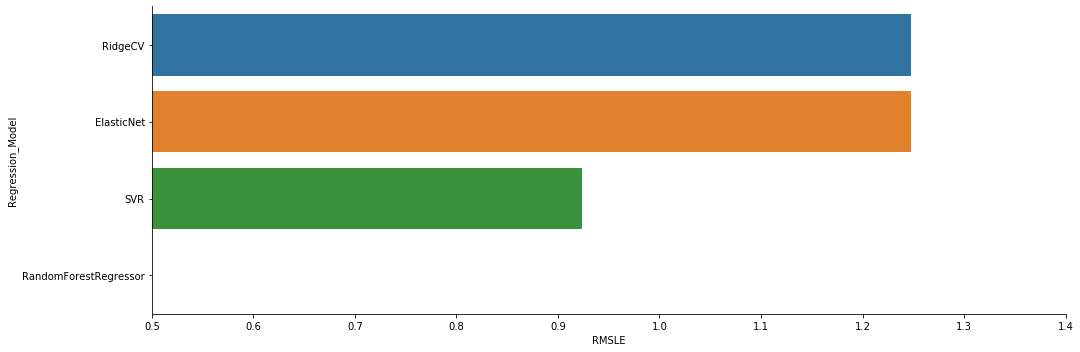

In [80]:
# plot RMSLE value per Regressor:
fig = sns.catplot(y='Regression_Model', x='RMSLE', data=df_rmsle,
                  kind='bar',height=5,aspect=3)
fig.set(xlim=(0.5, 1.4))

## Conclusion

Preferred model here is RandomForestRegressor as 
- training and test score are hardly differing
- no overfitting obvious
- best test score
- smallest RMSLE